# Lab 4: Stochastic gradient and $\ell^1$ regularization

**Report by Ugo Roccamatisi.**


<h1><a id='toc'></a>Contents</h1>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ul>
        <li><a href="#I">I. Introduction </a></li>
        <ul>
        <li><a href="#I1">I.1. A one-dimensional example</a></li>
        <li><a href="#I2">I.2. A degenerate case</a></li>
        <li><a href="#I3">I.3. A higher-dimensional example</a></li>
        </ul>
        <li><a href="#II">II. Numerical optimization of $F_\lambda$ with ISTA</a></li>
        <ul>
            <li><a href="#II1">II.1. Fixed-step gradient descent revisited</a></li> 
            <li><a href="#II2">II.2. ISTA </a></li> 
        </ul>
        <li><a href="#III">III. Application to stochastic optimization</a></li>
    </ul>
</div>
<br>
<hr>

Imports

In [1]:
# The teaching library toynn_2023 was not provided: the final
# experiment uses a small self-contained NumPy network, defined below.
import numpy as np
from numpy import random as nprd
from matplotlib import pyplot as plt
import math as mt
from numpy import linalg as ln
nprd.seed(2025)

# I. Introduction <a id='I'></a>

<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I3">I.3</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II1">II.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II2">II.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

We want to minimize a smooth convex objective function $F(w)$, but we also want to favor sparse solutions, i.e. parameters $w$ with many zero components. To do so, we penalize the objective by adding the "regularization" term $\lambda\|w\|_1$. Here $\lambda\geq0$ is the penalty parameter and
$$
\|w\|_1 :=\sum_{j=0}^{N-1}|w_j|=|w_0|+|w_1|+\dots+|w_{N-1}|
$$
is the $\ell^1$ norm of the vector $w$.

<a id='I1'></a>
<h2>I.1. A one-dimensional example</h2>

<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I3">I.3</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II1">II.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II2">II.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

First consider the case $N=1$. Let $\,\bar w\in\mathbb{R}\,$. Define $\,f(w)=\frac12|w-\bar w|^2\,$ and, for $\,\lambda\ge 0\,$, let
$$\,f_\lambda(w):=f(w)+\lambda\|w\|_1\,=\, \frac12|w-\bar w|^2+\lambda|w|.$$
The minimizer of $\,f\,$ is obviously $\,\bar w\,$. How much is it perturbed by the regularization term? Let us find out by computing the minimizer of $\,f_\lambda$.

**Preliminary remarks.** The function $f$ is strictly convex (it is 1-convex) and $w\mapsto |w|$ is convex, so $f_\lambda$ is $1$-convex. We conclude that $f_\lambda$ has a unique minimizer, denoted $w^*$ as usual.

For $\lambda>0$, $f_\lambda$ is not differentiable at $0$. However, it is differentiable at every $w\neq0$, and if $w^*\neq 0$ we have the optimality condition

$$
0=f'_\lambda(w^*)=w^*-\bar w +\lambda \mathop{sign}(w^*). \tag{0}
$$
Conversely, if (0) holds at a point $\hat w\neq0$, then $\hat w =w^*$.

We distinguish four cases depending on the values of $\bar w$ and $\lambda$.

**1. First case**$\,$ If $\bar w=0$, obviously $w^*=0$ $~~$($\,f_\lambda(0)=0\,$ and $\, f_\lambda(w)>0\,$ if $\,w\neq0\,$).

**2. Second case**$\,$ If $\lambda=0\,$ then $\,f_\lambda(w)=f(w)=\frac12|w-\bar w|^2\,$ and the minimizer is $\,w^*=\bar w$.

**3. Third case** $\,$Assume $\,\lambda>0\,$ and $\,\bar w>0\,$. First note that $\,w^*\geq 0$.
Indeed, for $\,w<0\,$, $\quad|w-\bar w|= \bar w - w>\bar w = |0-\bar w|,\quad $ so
$\quad
f_\lambda(w)>f_\lambda(0)\geq f_\lambda(w^*)
\quad$ and therefore $\,w^*\neq w$.

Then, if $\,w^*>0\,$, (0) gives $\,w^*=\bar w-\lambda$. This number is positive if and only if $\,\bar w>\lambda$. We conclude that:

$$
w^*=\begin{cases}\bar w-\lambda &\text{if } \bar w>\lambda,\\
\quad 0 & \text{if } 0<\bar w\leq\lambda. \end{cases}
$$

**4. Fourth case** Still assume $\,\lambda>0\,$ but now $\,\bar w<0$. Reasoning as above, $\,w^*\leq 0\,$ and

$$
w^*=\begin{cases}\bar w+\lambda &\text{if } \bar w<-\lambda,\\
\quad 0 & \text{if } -\lambda\leq \bar w<0. \end{cases}
$$

**Conclusion** $\,$In summary:
$$
w^*=\begin{cases}\bar w-\lambda\ \text{sign}\,\bar w &\text{if } |\bar w|>\lambda,\\
\qquad 0 & \text{if } |\bar w|\leq \lambda. \end{cases}
$$

The distance between the minimizer of $\,f\,$ and the minimizer of $\,f_\lambda\,$ is:

$$
|\bar w|>\lambda\ \Longrightarrow\ |w^* -\bar w|=\lambda\qquad\text{and}\qquad
|\bar w|\le\lambda\ \Longrightarrow\ |w^* -\bar w|=|\bar w|.
$$

In all cases:$\qquad\qquad\qquad\qquad\qquad|w^* -\bar w|\leq \lambda$.

Below are the plots of the map $\bar w\mapsto w^*$ for $\lambda =0$, $\lambda=1$, $\lambda=2$ and $\lambda=4$.

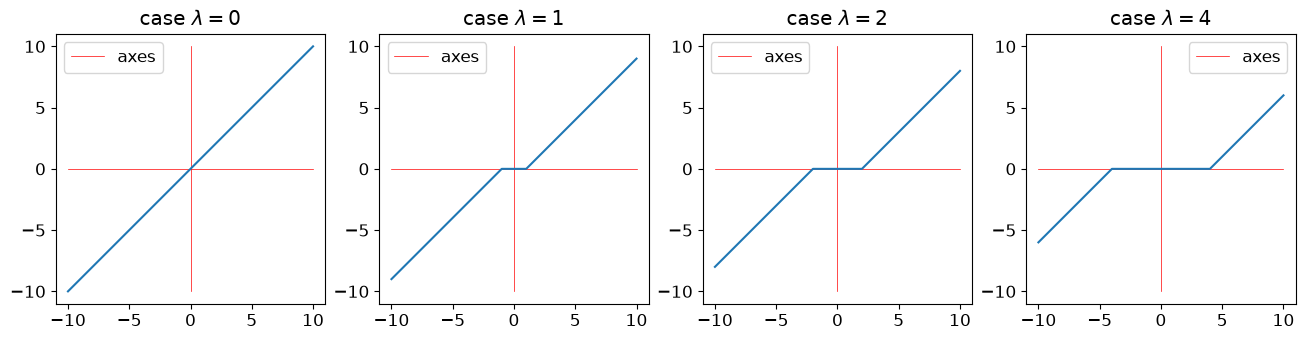

In [2]:
plt.rcParams.update({'font.size': 12})
if 1==1:
    buildf_lbda = lambda L: lambda w: np.where(w>L, w-L, 
                                               np.where( w<-L, w+L, 0))
    lbda = (0 , 1, 2 , 4)
    w=np.linspace(-10,10,41)
    plt.figure(figsize=(16,3.5))
    for i in range(4):
        plt.subplot(141 + i)
        plt.plot([-10, 10], [0, 0],'r',linewidth=.5, label='axes')
        plt.plot([0, 0], [-10, 10],'r',linewidth=.5)
        plt.plot(w, buildf_lbda(lbda[i])(w))
        plt.title(r"case $\lambda=$" + str(lbda[i]))
        plt.legend()

<a id='I2'></a>
<h2>I.2. A degenerate case</h2>

<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I3">I.3</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II1">II.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II2">II.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

Here we take $N=2$ and 
$$
F(w):=\dfrac12(2w_0 + w_1 - 1)^2.
$$

**Exercise 1**

a) Is $F$ convex? Strongly convex? Coercive?

b) Find the minimizers of $F$ in $\mathbb{R}^2$.

c) Let $\lambda>0$. Find the minimizers of

$$
F_\lambda(w)=F(w)+\lambda\|w\|_1:= \dfrac12(2w_0 + w_1 - 1)^2 +\lambda (|w_0| +|w_1|).
$$

*__Hint:__ show that if the component $w^*_j$ of a minimum point $w^*$ is non-zero, then $\dfrac {\partial F_\lambda(w^*)}{\partial w_j}$ is well defined and equal to zero.*

d) Interpret the result of (c): what are the effects of the regularization term $\lambda \|w\|_1$?

**Solution 1.a.** $F(w)=\frac12(2w_0+w_1-1)^2$ is convex: its Hessian $\begin{pmatrix}4&2\\2&1\end{pmatrix}$ is positive semi-definite but of rank 1. It is neither strongly convex nor coercive: along $(w_0,w_1)=(t,1-2t)$ it is always zero while the norm goes to infinity.

**Solution 1.b.** Every point of the line $2w_0+w_1=1$ minimizes $F$, with minimum value $0$.

**Solution 1.c.** For a fixed value $t=2w_0+w_1$, $|w_0|+|w_1|\ge |t|/2$, with equality only for $w_0=t/2,w_1=0$. It remains to minimize $\frac12(t-1)^2+\frac\lambda2|t|$, whose solution is $t^*=\max(1-\lambda/2,0)$. For $0<\lambda<2$, the unique minimizer is $(1/2-\lambda/4,0)$; for $\lambda\ge2$, it is $(0,0)$.

**Solution 1.d.** The penalty selects a sparse minimizer along a flat direction of the original problem; as soon as $\lambda>0$, the component $w_1$ is exactly zero. For $\lambda\ge2$, the whole vector becomes zero.

<a id='I3'></a>
<h2>I.3. A higher-dimensional example</h2>

<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I3">I.3</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II1">II.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II2">II.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

Now consider a non-degenerate quadratic function as in **I.1**, but in higher dimension $N\geq 1$. Fix $\bar w\in \mathbb{R}^N$ and numbers $a_0,a_1,\dots,a_{N-1}>0$, and let, for $w\in\mathbb{ R}^N$,

$$\tag{1}
F(w):=\dfrac12\sum_{j=0}^{N-1} a_j (w_j-\bar w_j)^2\qquad\qquad\qquad\qquad\qquad\qquad\qquad\qquad
\qquad\qquad=\dfrac{a_0}2(w_0-\bar w_0)^2 + \dfrac{a_1}2(w_1-\bar w_1)^2+\dots + \dfrac{a_{N-1}} 2(w_{N-1}-\bar w_{N-1})^2.
$$

As in part <a href="#I1">I.1.</a>, $\,F\,$ is strongly convex: it is $\gamma$-convex with
$$\gamma=\min\{a_j,j=0,\dots,N-1\}\, >0.$$
$\,\bar w\,$ is the unique minimizer of $\,F$.

Fix $\lambda>0$ and, as above, let $F_\lambda(w):=F(w)+\lambda \|w\|_1$. $F_\lambda$ is again strongly convex; we denote its unique minimizer $w^*$. 

How far is $w^*$ from $\bar w$? How much sparser is it than $\bar w$? To find out, we compute $w^*$ explicitly.

First note that $F_\lambda$ splits into $N$ functions of a single parameter:

$$
F_\lambda(w)=\sum_{j=0}^{N-1} F^{(j)}_\lambda (w_j)\qquad
\text{with}\quad F^{(j)}_\lambda (w_j)=\dfrac{a_j}2(w_j-\bar w_j)^2 + \lambda |w_j|
= a_j\left\{\dfrac12(w_j-\bar w_j)^2 + \dfrac{\lambda}{a_j} |w_j|\right\}.
$$

Since the parameters of the functions $F_\lambda^{(j)}$ are independent of each other, we can minimize each $F_\lambda^{(j)}$ separately. The expression in braces has the form $f_{\lambda/a_j}(w_j)$ studied in <a href="#I1">I.1.</a> We deduce that

$$\tag{2}
\text{For }j=0,\dots,N-1,\ \quad w^*_j=\begin{cases}\bar w_j-\dfrac\lambda{a_j}\ \text{sign}\, \bar w_j &\text{if } |a_j\bar w_j|>\lambda,\\
\qquad 0 &\text{if } |a_j\bar w_j|\leq \lambda. \end{cases}
$$

Note that $|a_j\bar w_j|= \left| \dfrac{\partial F}{\partial w_j}(0)\right|$ measures the sensitivity of $F$ to variations of the $j$-th variable.

The formula above can be interpreted as follows:

$\quad\ $a) if this sensitivity is small enough, _i.e._ $\ \left| \dfrac{\partial F}{\partial w_j}(0)\right|\leq \lambda\ $, then $w^*_j=0$, and
$$
\tag{3a}
|a_j(w^*_j - \bar w_j)| \leq\lambda.
$$


$\quad\ $b) for larger sensitivities $\ \left| \dfrac{\partial F}{\partial w_j}(0)\right| > \lambda\ $, $w^*_j$ is an approximation of $\bar w_j$, with
$$
\tag{3b}
|a_j(w^*_j - \bar w_j)| =\lambda.
$$

**Remark.** The optimality conditions of the $\ell^1$ penalty give, for each $j$,
$$
\left|\frac{\partial F(w^*)}{\partial w_j}\right|\leq\lambda.
$$
With all other coordinates fixed at their value in $w^*$, define
$$
S_j=\left\{t\in\mathbb R:\left|\frac{\partial F}{\partial w_j}
(w_0^*,\ldots,w_{j-1}^*,t,w_{j+1}^*,\ldots,w_{N-1}^*)\right|\leq\lambda\right\}.
$$
Then $w_j^*$ is a point of $S_j$ that minimizes $|t|$: thresholding favors the zero coordinate as soon as it satisfies the gradient bound. This characterization also holds for a convex differentiable $F$.


We see that if $\lambda$ is small, $w^*$ is a small perturbation of the exact minimizer of $F$. Moreover, if setting $w^*_j$ to 0 only creates a negligible gradient (smaller than $\lambda$), then $w^*_j=0$. In this sense, the regularization favors *sparsity* of $w^*$.

# II. Numerical optimization of $F_\lambda$ with ISTA<a id='II'></a> 

<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I3">I.3</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II1">II.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II2">II.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

__(__ ***ISTA stands for Iterative Shrinkage-Thresholding Algorithm*** __)__

We want to minimize a smooth convex function $F:\mathbb{R}^N\to \mathbb{R}$ with a regularization term $\lambda \|w\|_1$, where $\lambda\geq 0$ is given.

<a id='II1'></a>
<h2>II.1. Fixed-step gradient descent revisited</h2>

<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I3">I.3</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II1">II.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II2">II.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

First assume $\,\lambda =0$. Then $\,F_\lambda=F\,$ is smooth and we can use gradient descent with a fixed step $\,\alpha>0$. We start by reinterpreting this method as a sequence of optimization problems. Starting from an initial vector $\,w^0\in\mathbb{R}^N\,$, we recursively build the sequence $w^0$, $w^1$, $w^2$, $\dots$ with the following rules:

$\qquad$a) At step $\,k$, given the current iterate $\,w^k$, define the function

$$\tag{5}
\Phi^k(w):=F(w^k) +\left<\nabla F(w^k);w-w^k\right> + \dfrac1{2\alpha}\|w-w^k\|^ 2
$$

To build $\,\Phi^k\,$, we started from the first-order Taylor expansion of $F$ and added the quadratic term $\,\|w-w^k\|^2/(2\alpha)$. $\Phi^k$ is therefore a (first-order) approximation of $\,F\,$ near $\,w^k\,$ and a positive-definite quadratic function.
In particular, it has a unique minimizer.

$\qquad$b) $w^{k+1}\,$ is defined as the minimizer of $\,\Phi^k$.

The minimizer of the quadratic function $\Phi^k$ is easy to find:

$$
\tag{6}
w^{k+1} = w^k - \alpha \nabla F(w^k)
$$

As announced, we recover the update of $\,w^{k+1}\,$ from $w^k$ of gradient descent with step $\alpha$.

**Exercise 2** Justify formula (6).

**Solution 2.** The gradient of the model $\Phi^k$ at $w$ is $\nabla F(w^k)+(w-w^k)/\alpha$. Setting it to zero gives $w^{k+1}=w^k-\alpha\nabla F(w^k)$, i.e. formula (6).

<a id='II2'></a>
<h2>II.2. ISTA</h2>

<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I3">I.3</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II1">II.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II2">II.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

We now assume $\lambda>0$, so that there is an $\ell^1$ regularization term. To minimize $F_\lambda$, we still start from an initial guess $w^0$ and recursively build a sequence $w^0$, $w^1$, $w^2$, $\dots$ where, at step $k,\,$ $w^{k+1}$ is the minimizer of

$$\tag{7}
\Phi_\lambda^k(w):= \Phi^k(w)+\lambda \|w\|_1.
$$

Note that we **do not replace** the penalty term by its Taylor expansion around $w^k$.

Recalling the definition of $\ \Phi^k,\ $ we have
$$\tag{8}
\Phi_\lambda^k(w)=F(w^k) +\left<\nabla F(w^k);w-w^k\right> + \dfrac1{2\alpha}\|w-w^k\| ^2 +\lambda\|w\|_1.
$$

Can we find an explicit formula for $w^{k+1}$? Yes! We are in fact in the situation of **I.3.** Let $\,\bar w^k\,$ be the minimizer of $\,\Phi^k$. By (6),

$$\tag{9}\bar w^k=w^k-\alpha\nabla F(w^k)$$

and $\Phi^k$ can be rewritten as
$$\tag{10}
\Phi^k(w) = c_k + \dfrac1{2\alpha} \|w - \bar w^k\|_2^2.
$$

**Exercise 3** Justify formula (10).

**Solution 3.** Expand $\|w-(w^k-\alpha\nabla F(w^k))\|^2/(2\alpha)$: this gives the linear term $\langle\nabla F(w^k),w-w^k\rangle$ and the quadratic term $\|w-w^k\|^2/(2\alpha)$; the remaining terms do not depend on $w$ and are gathered in $c_k$.

From (7) and (10), $w^{k+1}$ is the minimizer of
$$
G(w):=\dfrac1{2\alpha} \|w - \bar w_k\|_2^2 + \lambda \|w\|_1.
$$
This function has the form (1) of part **I.3.** with $a_0=a_1=\dots=a_{N-1}=1/\alpha$. Using formula (2), we get

$$\tag{11}
\text{for }j=0,\dots,N-1,\ \ w^{k+1}_j=
\begin{cases} \bar{w}^k_j - \lambda\alpha\ \text{sign}\, \bar w^k_j &
\text{if } |\bar{w}^k_j| > \lambda\alpha ,\\
\qquad 0 &
\text{if } |\bar{w}^k_j| \leq \lambda\alpha. \end{cases}\qquad
$$

**Summary.** From (9) and (11) we get an explicit formula for $w^{k+1}$. After initialization, ISTA runs as follows: for $k=0,1,\dots$ compute
$$\tag{12}
\begin{array}{rl} \hfill\bar{w}^k :=&w^k-\alpha\nabla F(w^k), \\ \\
\text{for }j=0,\dots,N-1,\quad \ w^{k+1}_j:=&
\begin{cases} \bar{w}^k_j - \lambda\alpha\ \text{sign}\, \bar w^k_j &
\text{if } |\bar{w}^k_j| > \lambda\alpha ,\\
\qquad 0 &
\text{if } |\bar{w}^k_j| \leq \lambda\alpha. \end{cases}
\end{array}
$$

**Exercise 4** We want to test this algorithm with
$$
F(w):=\sum_{j=0}^{N-1} \sin^2(\pi (w_j - w^*_j)),
$$
where the sequence $w^*_0,\dots,w^*_{N-1}$ is given.<br>
Justify the formula for $\nabla F$ given below in the definition of the Python function _buildGradF_.


**Solution 4.** For $F(w)=\sum_j\sin^2(\pi(w_j-w_j^*))$, the coordinates are independent. The chain rule gives $\partial_j F=2\pi\sin(\pi(w_j-w_j^*))\cos(\pi(w_j-w_j^*))=\pi\sin(2\pi(w_j-w_j^*))$.

In [3]:
## Example of a smooth non-convex function

# Builders for F and Grad F
buildF = lambda barw : lambda w : np.sum(
                            np.sin(np.pi*(w - barw))**2 )
buildGradF = lambda barw : lambda w : np.pi*np.sin(2*np.pi*(w - barw))

# Counts the number of non-zero components of a vector
count_non_zeros= lambda w: np.sum(np.where(w==0, 0, 1)) 

<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I3">I.3</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II1">II.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II2">II.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

**Exercise 5** Implement ISTA (complete the fourth cell below) for the previous function, with $N=100$ and $\lambda=2$. 

Plot the values of $F_\lambda$ along the iterations, as well as the number of non-zero components of each iterate.<br>

Vary $\lambda$ and write down your observations and comments in the dedicated cell.

_Hint:_ the numpy method _np.where_ can be useful. If _w_ is a numpy array, say a vector, the command
<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
v$=$np.where(abs(w)<1, f(w), g(w))<br>
builds a numpy array _v_ of the same size as _w_ with the following rule:
$$
\text{v}[i]=\begin{cases} \text{f}(\text{w}[i])&\text{if }\text{abs}(\text{w}[i])<1,\\
\text{g}(\text{w}[i])&\text{otherwise}.\end{cases}
$$

The $\ell^1$ norm of a numpy array _w_ is obtained with _numpy.linalg.norm_. For example, the command<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
norm_l1$=$ln.norm(w, ord=1)<br>
computes the sum $\sum_i|$*w*[$i$]$|$ (and assigns it to the variable *norm_l1*).


In [4]:
## (Setup for exercise 5)
# Problem definition
N = 100
w_star = .5*nprd.random(N) - .25
F, GradF = buildF(w_star), buildGradF(w_star)

In [5]:
## Step below 1/L: here L<=2π² for the gradient of F.
alpha=.04
Lambda=2
threshold=alpha*Lambda
Nitermax=80

In [6]:
## (Setup for exercise 5)
# Initialization
w = .5*nprd.random(N) - .25
niter=0

# Two lists to analyze the behavior of the optimization algorithm.
# E stores the values of the objective function.
E = [(F(w) + Lambda*ln.norm(w, ord=1))]
# NZ stores the number of non-zero entries of each w^k.
NZ = [count_non_zeros(w)] 

In [7]:
# Gradient step followed by coordinate-wise soft thresholding.
while niter<Nitermax:
    z=w-alpha*GradF(w)
    w=np.sign(z)*np.maximum(np.abs(z)-threshold,0)
    E.append(F(w)+Lambda*ln.norm(w,ord=1))
    NZ.append(count_non_zeros(w))
    niter+=1
print('Initial/final Fλ:',round(E[0],4),round(E[-1],4),'; non-zero coefficients:',NZ[0],NZ[-1])

Initial/final Fλ: 58.748 17.9899 ; non-zero coefficients: 100 62


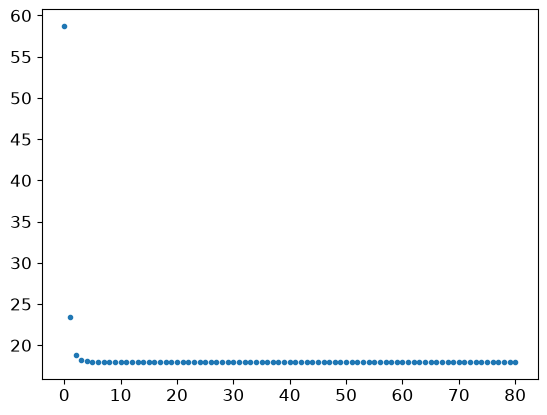

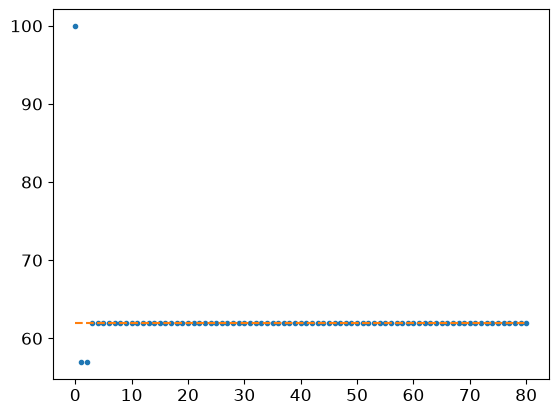

In [8]:
# Solution 5 (continued): plots.
E = np.array(E)
minE = np.min(E)
plt.plot(E,".")
plt.show()


plt.plot(NZ,".")
plt.plot([0, Nitermax],[NZ[-1],NZ[-1]],"--")
plt.show()



In [9]:
# Comparison from the same starting point, without reusing previous iterates.
initial=np.random.default_rng(7).uniform(-.25,.25,size=N)
for lam in (.5,2.,5.):
    trial=initial.copy()
    for _ in range(80):
        z=trial-alpha*GradF(trial)
        trial=np.sign(z)*np.maximum(np.abs(z)-alpha*lam,0)
    print(f'λ={lam}: F={F(trial):.3f}, Fλ={F(trial)+lam*np.abs(trial).sum():.3f}, non-zeros={np.count_nonzero(trial)}')

λ=0.5: F=0.588, Fλ=6.193, non-zeros=90
λ=2.0: F=8.680, Fλ=17.990, non-zeros=62
λ=5.0: F=20.698, Fλ=20.698, non-zeros=0


**Solution 5: results.** From this starting point, λ=0.5 keeps 90 non-zero coefficients, λ=2 keeps 62 and λ=5 gives the zero vector. The value of F alone increases with the sparsity pressure: the penalty changes the objective being minimized.


**Exercise 6** Consider the function

$$
F(w):=\sum_{j=0}^{N-1} \sin^2(w_j - w_{j-1}),
$$
where the indices $j$ are taken modulo $N$.

a) Justify the formula for $\nabla F$ given in the next cell.

b) What are the minimizers of $F$?

c) What are the minimizers of $F_\lambda$ for $\lambda>0$?

d) Apply your ISTA implementation to minimize $F_\lambda$. For $\lambda=0$, do the iterates converge to a minimizer of $F$?

e) For $\lambda>0$, do the iterates converge to a minimizer of $F_\lambda$? If not, why?

f) Do the iterates converge to a vector close to a minimizer of $F$? Are the solutions sparse? Are your numerical results consistent with (3a)–(3b)? Justify.

In [10]:
F = lambda w : np.sum( np.sin(w - np.roll(w,1))**2 )
GradF = lambda w : 2*np.sin(2*w - np.roll(w,1) - np.roll(w,-1))*np.cos(np.roll(w,1)                                                                   - np.roll(w,-1))

**Solution 6.** The derivative of $\sin^2(w_j-w_{j-1})$ with respect to $w_j$ is $\sin(2(w_j-w_{j-1}))$; that of the next term is $-\sin(2(w_{j+1}-w_j))$. Their difference can be rewritten in the given form with the sine difference identity. The global minimizers of $F$ satisfy $w_j-w_{j-1}\in\pi\mathbb Z$ for all j (around the cycle); there are infinitely many. For λ>0, $F_λ\ge0$ and the zero vector is its **unique** global minimizer. F is non-convex: ISTA with an admissible step can converge to a non-global stationary point, so there is no guarantee of convergence to zero from an arbitrary start. A stationary iterate satisfies $|\partial_jF(w)|\le\lambda$, with equality in modulus if $w_j\ne0$. Thresholding favors exact zeros, but how close the result is to a minimizer of F depends on the starting point and on λ.

**Numerical results.** Here, λ=0 approaches a minimizer of F (F≈2.7×10⁻⁴) but keeps 100 non-zero coefficients; the three tested values λ>0 converge to the zero vector, which minimizes Fλ. This observation for one starting point does not prove global convergence from every start.


λ=0: Fλ=0.00027, F=0.00027, non-zeros=100, max|∂F|=0.0011
λ=0.05: Fλ=0.00000, F=0.00000, non-zeros=0, max|∂F|=0.0000
λ=0.2: Fλ=0.00000, F=0.00000, non-zeros=0, max|∂F|=0.0000
λ=1.0: Fλ=0.00000, F=0.00000, non-zeros=0, max|∂F|=0.0000


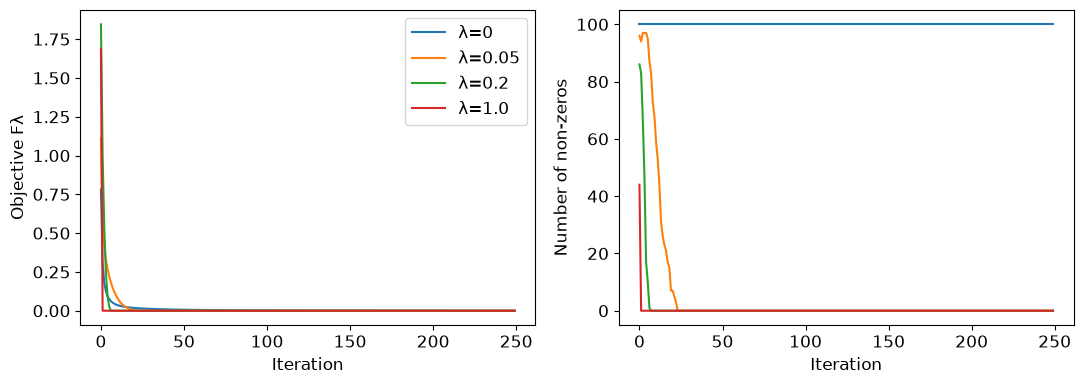

In [11]:
# Exercise 6 experiment: same starting point for every λ.
F_ring=F;Grad_ring=GradF
r0=np.random.default_rng(123).uniform(-.25,.25,size=100)
fig,axes=plt.subplots(1,2,figsize=(11,4))
for lam in (0,.05,.2,1.):
    v=r0.copy();values=[];counts=[]
    for _ in range(250):
        z=v-.10*Grad_ring(v)
        v=np.sign(z)*np.maximum(np.abs(z)-.10*lam,0)
        values.append(F_ring(v)+lam*np.abs(v).sum());counts.append(np.count_nonzero(v))
    axes[0].plot(values,label=f'λ={lam}');axes[1].plot(counts,label=f'λ={lam}')
    print(f'λ={lam}: Fλ={values[-1]:.5f}, F={F_ring(v):.5f}, non-zeros={counts[-1]}, max|∂F|={np.max(np.abs(Grad_ring(v))):.4f}')
axes[0].set(xlabel='Iteration',ylabel='Objective Fλ');axes[1].set(xlabel='Iteration',ylabel='Number of non-zeros')
axes[0].legend();fig.tight_layout();plt.show()

# III. Application to stochastic optimization <a id='III'></a>

<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I3">I.3</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II1">II.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II2">II.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

__Exercise 7.__


a) Implement ISTA for the classification problem and toy neural networks defined below, with learning rate $\alpha=5\cdot10^{-2}$ and $\lambda=10^{-3}$.

Compared with ISTA, the algorithm changes as follows:

$\qquad\alpha$) in the first step of (12), $\nabla F(A)$ is replaced by the mean of the $\nabla f_i(A)$ over a mini-batch $I$ of randomly drawn indices.

$\qquad\beta$) a decreasing learning-rate schedule is used.

To study the algorithm (graphically), store the total error on the training set and the number of non-zero components of the parameter $A$ along the epochs.

*Hints:*<br> 
$\qquad\qquad\bullet$ The method _nn.count_non_zero(A)_ returns the number of non-zero components of the list of coefficients _A_.<br> 
$\qquad\qquad\bullet$ Combined with *np.where()*, the method *nn.maps()* is very handy to compute the ISTA iterates.<br>If $f$ is a function taking a numpy array _X_ and (optionally) a parameter _p_ and returning an array of the same size as _X_, then _nn.maps(f,A,param=p, output=False)_ replaces every coefficient $A_i$ of _A_ by *f(*$A_i$*,p)*.<br>




b) Observe the numerical results obtained with the parameters proposed in the next two cells. 

c) Try different values of $\lambda$ and comment.

**Solution 7.** Since `toynn_2023` was not provided, the network part is implemented below with a NumPy network (2–8–8–8–1) on an equivalent ring classification problem. The loss gradient is averaged over each mini-batch, followed by soft thresholding of the weights; biases are not penalized. A decreasing learning rate damps the oscillations. The figures and decision boundaries are those of this self-contained implementation, not of the missing teaching library.

**Numerical results.** After 400 epochs, test accuracy is about 0.825 without penalty, 0.805 for λ=0.001 (141 non-zero weights out of 152), and 0.703 for λ=0.01 (all penalized weights vanish). Here a penalty that is too strong destroys the classification capacity.


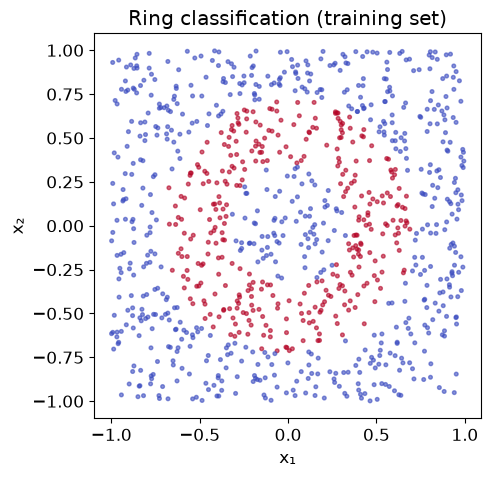

Training classes: [662 338]


In [12]:
# Reproducible "ring" dataset, two classes: center + outside vs annular band.
from scipy.special import expit
rng_ring=np.random.default_rng(2025)
X_ring=rng_ring.uniform(-1,1,size=(1400,2))
radius=np.linalg.norm(X_ring,axis=1)
y_ring=((radius>.35)&(radius<.72)).astype(float)
X_tr,X_te=X_ring[:1000],X_ring[1000:]
y_tr,y_te=y_ring[:1000],y_ring[1000:]
fig,ax=plt.subplots(figsize=(5,5));ax.scatter(*X_tr.T,c=y_tr,cmap='coolwarm',s=7,alpha=.6)
ax.set(xlabel='x₁',ylabel='x₂',title='Ring classification (training set)');plt.show()
print('Training classes:',np.bincount(y_tr.astype(int)))

In [13]:
# Fully connected network: three tanh hidden layers, sigmoid output.
shape=(2,8,8,8,1);n_epochs=400;batch_size=64
initial_rng=np.random.default_rng(41)
initial_W=[initial_rng.normal(scale=np.sqrt(2/(a+b)),size=(a,b)) for a,b in zip(shape[:-1],shape[1:])]
initial_b=[np.zeros((1,b)) for b in shape[1:]]

def forward(X,weights,biases):
    activations=[X]
    for W,b in zip(weights[:-1],biases[:-1]):activations.append(np.tanh(activations[-1]@W+b))
    activations.append(expit(activations[-1]@weights[-1]+biases[-1]))
    return activations

def loss_and_grads(X,y,weights,biases):
    act=forward(X,weights,biases);p=act[-1].ravel();target=y.ravel()
    pclip=np.clip(p,1e-12,1-1e-12)
    loss=-np.mean(target*np.log(pclip)+(1-target)*np.log1p(-pclip))
    delta=((p-target)/len(X))[:,None];dW=[None]*len(weights);db=[None]*len(weights)
    for j in range(len(weights)-1,-1,-1):
        dW[j]=act[j].T@delta;db[j]=delta.sum(axis=0,keepdims=True)
        if j:delta=(delta@weights[j].T)*(1-act[j]**2)
    return loss,dW,db

In [14]:
def train_stochastic_ista(lam,seed=60):
    W=[w.copy() for w in initial_W];b=[v.copy() for v in initial_b]
    local_rng=np.random.default_rng(seed);losses=[];counts=[];acc=[]
    for epoch in range(n_epochs):
        lr=.05/np.sqrt(1+epoch/30)  # step decreasing with the epoch.
        for idx in np.array_split(local_rng.permutation(len(X_tr)),int(np.ceil(len(X_tr)/batch_size))):
            _,dW,db=loss_and_grads(X_tr[idx],y_tr[idx],W,b)
            # Stochastic gradient step, then L1 proximal operator on the weights.
            W=[np.sign(z)*np.maximum(np.abs(z)-lr*lam,0) for z in (w-lr*dw for w,dw in zip(W,dW))]
            b=[bb-lr*dbb for bb,dbb in zip(b,db)]
        objective,_,_=loss_and_grads(X_tr,y_tr,W,b)
        losses.append(objective);counts.append(sum(np.count_nonzero(w) for w in W))
        acc.append(np.mean((forward(X_te,W,b)[-1].ravel()>=.5)==y_te))
    return W,b,np.asarray(losses),np.asarray(counts),np.asarray(acc)
print('Network weights:',sum(w.size for w in initial_W),'(biases not penalized)')

Network weights: 152 (biases not penalized)


In [15]:
# Requested setting: initial α=0.05 and λ=10⁻³; other values for comparison.
experiments={lam:train_stochastic_ista(lam) for lam in (0,.001,.01)}
for lam,(_,_,losses,counts,acc) in experiments.items():
    print(f'λ={lam}: train loss={losses[-1]:.4f}, test accuracy={acc[-1]:.3f}, non-zero weights={counts[-1]}/{counts[0]}')

λ=0: train loss=0.3475, test accuracy=0.825, non-zero weights=152/152
λ=0.001: train loss=0.3880, test accuracy=0.805, non-zero weights=141/152
λ=0.01: train loss=0.6397, test accuracy=0.703, non-zero weights=0/149


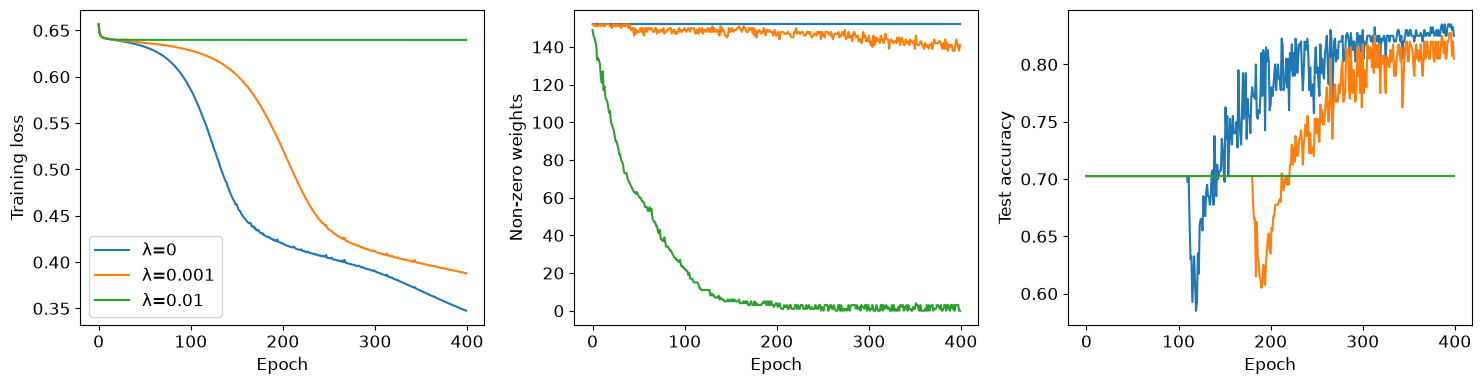

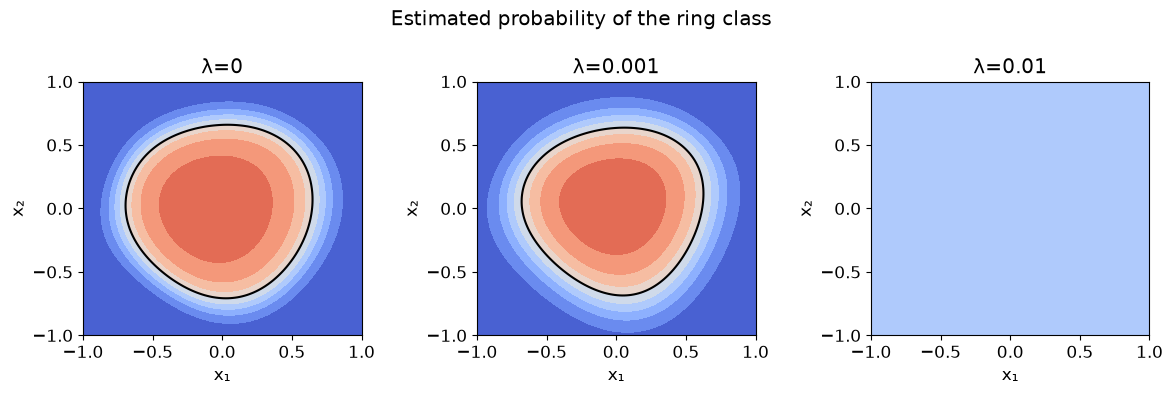

In [16]:
fig,axes=plt.subplots(1,3,figsize=(15,4))
for lam,(_,_,losses,counts,acc) in experiments.items():
    axes[0].plot(losses,label=f'λ={lam}');axes[1].plot(counts,label=f'λ={lam}');axes[2].plot(acc,label=f'λ={lam}')
axes[0].set(xlabel='Epoch',ylabel='Training loss');axes[1].set(xlabel='Epoch',ylabel='Non-zero weights')
axes[2].set(xlabel='Epoch',ylabel='Test accuracy');axes[0].legend();fig.tight_layout();plt.show()
fig,axes=plt.subplots(1,3,figsize=(12,4))
xx,yy=np.meshgrid(np.linspace(-1,1,120),np.linspace(-1,1,120));grid=np.c_[xx.ravel(),yy.ravel()]
for ax,(lam,(W,b,_,_,_)) in zip(axes,experiments.items()):
    prob=forward(grid,W,b)[-1].reshape(xx.shape)
    ax.contourf(xx,yy,prob,levels=np.linspace(0,1,11),cmap='coolwarm',vmin=0,vmax=1)
    ax.contour(xx,yy,prob,levels=[.5],colors='k')
    ax.set(title=f'λ={lam}',xlabel='x₁',ylabel='x₂')
fig.suptitle('Estimated probability of the ring class');fig.tight_layout();plt.show()

<a id='bot'></a>
<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I3">I.3</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II1">II.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II2">II.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>